In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
import argparse

import numpy as np
import pandas as pd
import anndata
import torch

import csv
import gzip
import scanpy

import scipy.io
import numpy as np 
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context


# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7 # figure.titlesize
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}



/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# --- INIT ---


# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided' # 'transformed_X_outlier_variance'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)
subclustering_folder = '%s/subclustering/res_%s' % (clustering_folder,subcluster_resolution)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % (subclustering_folder)






In [3]:
# --- LOAD THE ADATA ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [27]:
# --- LIST GENES ---

# genes_of_interest = ['Myh11', 'Serpinf1', 'Pecam1', 'Cd68', 'Hba-a2', 'Cd4', 'Cd3g', 'Cd3d', 'Plp1', 'Nrgn']

# genes_of_interest = ['Spp1', 'Mgp', 'Thbs1', 'Aqp1', 'Adh1b', 'Cfh', 'Cd74', 'Depp1', 'Igfbp7', 'Clu', 'Igfbp5', 'Bgn', 'Mt1x', 'Aebp1', 'Adirf']

# genes_of_interest = ['Spp1', 'Ly6a', 'Gja1', 'Sparcl1', 'Il1r1', 'Irf1', 'Rgs5', 'Wif1', 'Tpan15', 'Grem1', 'Pde1c', 'Hand2', 'Hoxa7', 'Tnc', 'Calcrl', 'Aspn', 'Gpc3']

genes_of_interest = ['Myh11','Acta2', 'Tagln', "Ptgs2", 'Lpl','C7']


# gene_string = 'CUL9;INTS13;BTG2;BTG1;NUMA1;HNRNPU;SLK;NEK1;MAP4K5;MAP4K3;TMEM8B;MAP4K4;MAP3K2;MAP4K2;DYNC1H1;STRADA;SCRIB;SIRT1;CDK11B;CDK8;CYLD;DLG1;RPS6KB1;TAOK1'
# genes_of_interest = list(map(lambda x: x.lower().capitalize(), gene_string.split(";")))


# genes_of_interest = ['Sox10', 'Hoxa9', 'Nfkb1', 'Atf3', 'Rgs5', 'Fn1', 'Col1a1', 'Klf4', 'Mgp', 'Eln', 'Acta2', 'Myh11', 'Lum', 'Spp1', 'Mmp9', 'Icam1', 'Cd34', 'Cd44', 'Bgn', 'Dcn', 'Cd45', 'Cd68', 'Itgam', 'Adgre1', 'Sp7', 'Sox9', 'Msx2', 'Runx2', 'Ucp1', 'Elovl3', 'Adipoq', 'Prdm16', 'Ppargc1a']
genes_of_interest = list(filter(lambda x: x in adata.var_names,genes_of_interest))
# with open('/users/mingyaolab/desktop/markers_2.txt') as file_obj:
#     genes_of_interest = list(map(lambda x: x.replace("\n",""), file_obj.readlines()))
    
# genes_of_interest = []
# genes_of_interest += ['Lgals3', 'Rgs5']



genes_of_interest



['Myh11', 'Acta2', 'Tagln', 'Ptgs2', 'Lpl', 'C7']

In [28]:
# --- SUBSAMPLE ADATA ---

import helper_functions

# ** get transformed expression **
sub_adata = helper_functions.add_transformed_X_to_adata(adata[:,genes_of_interest],pseudocount=1e-7)

# ** limit to cluster **
# sub_adata = sub_adata[sub_adata.obs['cluster'] == 0]

# ** subsample cells **
# sampled_indices = np.random.choice(np.arange(0,sub_adata.shape[0]),min(10000,sub_adata.shape[0]),replace=False)
sampled_indices = np.random.choice(np.arange(0,sub_adata.shape[0]),min(145271,sub_adata.shape[0]),replace=False)

sub_adata = sub_adata[sampled_indices]
sub_adata



View of AnnData object with n_obs × n_vars = 145271 × 6
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'
    layers: 'X_transformed'

In [29]:
# # --- GET THE SMOOTHED EXPRESSION ---

# # set the bw
# bw = 0.1 # 0.5

# # compute 2d similarity
# dif_1 = sub_adata.obsm['X_scVI_umap'][:,0] - sub_adata.obsm['X_scVI_umap'][:,0].reshape(-1,1)
# dif_2 = sub_adata.obsm['X_scVI_umap'][:,1] - sub_adata.obsm['X_scVI_umap'][:,1].reshape(-1,1)
# log_sim = scipy.stats.norm(scale=bw).logpdf(dif_1) + scipy.stats.norm().logpdf(dif_2)
# sim = np.exp(log_sim)
# sim = sim / np.sum(sim,axis=1).reshape(-1,1) # make sure columns sum to 1


# # get the smoothed expression
# sub_adata.layers['X_transformed_smoothed'] = np.matmul(sim,sub_adata.layers['X_transformed'])



In [30]:
# # --- VIZ ---

# # get min and max vals
# x_min,y_min = np.min(sub_adata.obsm['X_scVI_umap'],axis=0)
# x_max,y_max = np.max(sub_adata.obsm['X_scVI_umap'],axis=0)
# x_min = x_min - np.abs(x_min) * 0.2
# y_min = y_min - np.abs(y_min) * 0.2
# x_max = x_max + np.abs(x_max) * 0.2
# y_max = y_max + np.abs(y_max) * 0.2



# # make plot for each time point
# for gene in genes_of_interest:

#     # get zt subcluster adata

#     # viz
#     fig,ax = plt.subplots(dpi=200)
#     sns.despine()
#     plt.scatter(sub_adata.obsm['X_scVI_umap'][:,0], sub_adata.obsm['X_scVI_umap'][:,1],s=2,c=sub_adata[:,gene].layers['X_transformed_smoothed'].flatten())
#     plt.xlim((x_min,x_max))
#     plt.ylim((y_min,y_max))
#     plt.title((gene))
#     plt.colorbar()
#     plt.xlabel("UMAP1")
#     plt.ylabel("UMAP2")
#     plt.show()



In [31]:
# # --- TEMP: LIMIT TO MALE CONTROL ---
# sub_adata = sub_adata[sub_adata.obs['description'] == 'male aligned bmal1-control']
# sub_adata


In [32]:
# # --- VIZ ---

# # get min and max vals
# x_min,y_min = np.min(sub_adata.obsm['X_scVI_umap'],axis=0)
# x_max,y_max = np.max(sub_adata.obsm['X_scVI_umap'],axis=0)
# x_min = x_min - np.abs(x_min) * 0.2
# y_min = y_min - np.abs(y_min) * 0.2
# x_max = x_max + np.abs(x_max) * 0.2
# y_max = y_max + np.abs(y_max) * 0.2



# # make plot for each time point
# for gene in genes_of_interest:
    
#     for zt in [0,6,12,18]:

#         # get zt subcluster adata
#         zt_sub_adata = sub_adata[sub_adata.obs['zt'] == zt]

#         # viz
#         fig,ax = plt.subplots(dpi=200)
#         sns.despine()
#         plt.scatter(zt_sub_adata.obsm['X_scVI_umap'][:,0], zt_sub_adata.obsm['X_scVI_umap'][:,1],s=2,c=zt_sub_adata[:,gene].layers['X_transformed'].flatten())
#         plt.xlim((x_min,x_max))
#         plt.ylim((y_min,y_max))
#         plt.title((gene))
#         plt.colorbar()
#         plt.xlabel("UMAP1")
#         plt.ylabel("UMAP2")
#         plt.show()



    
    

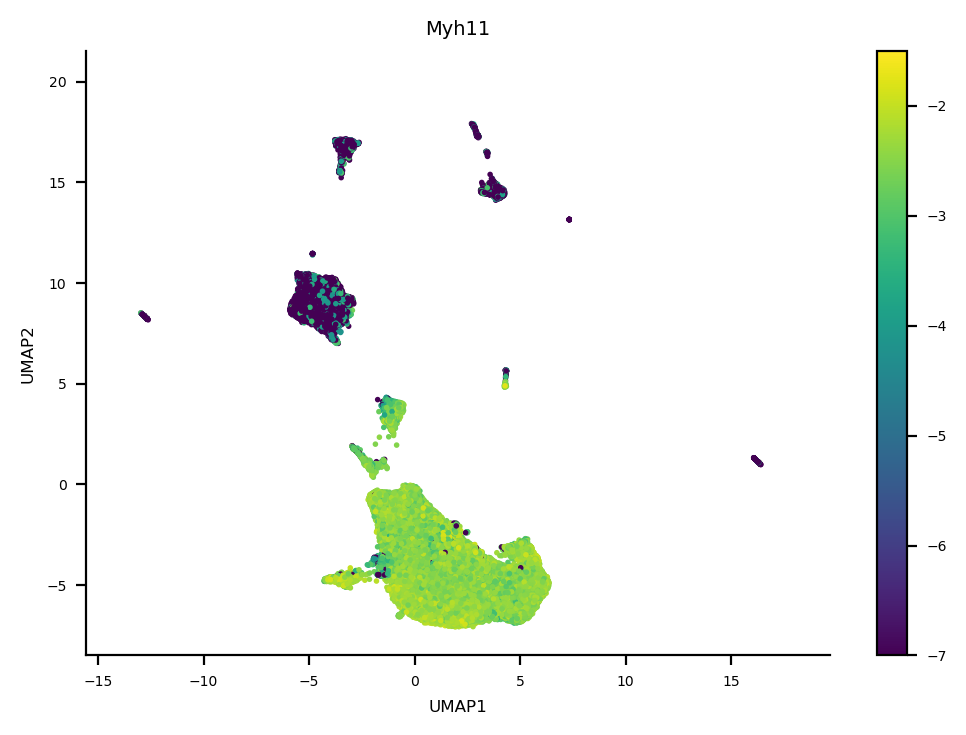

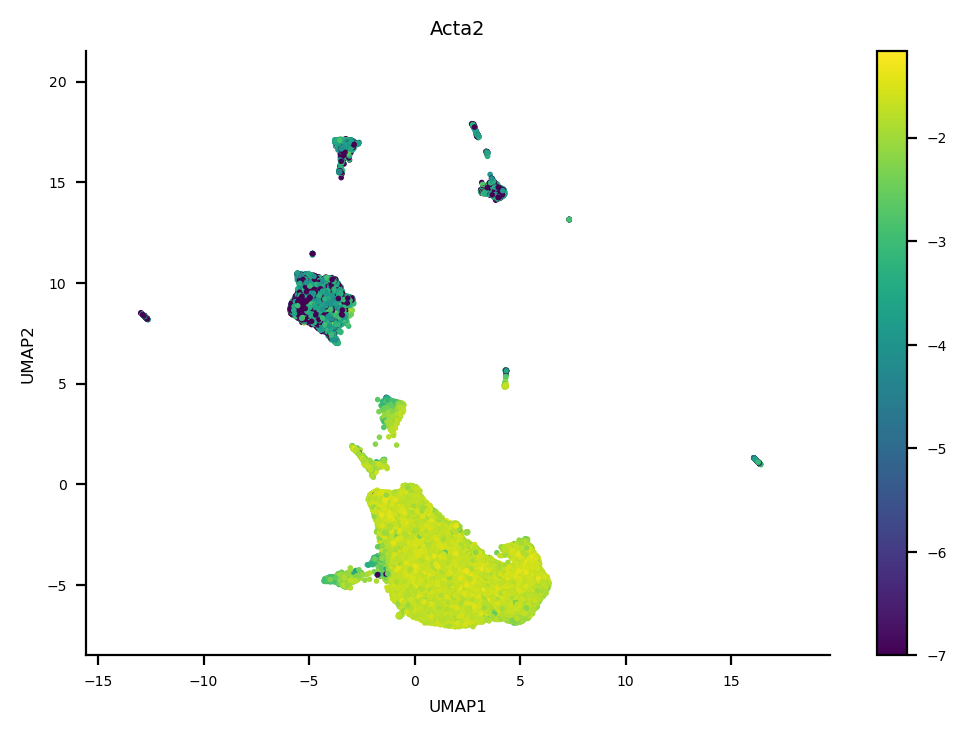

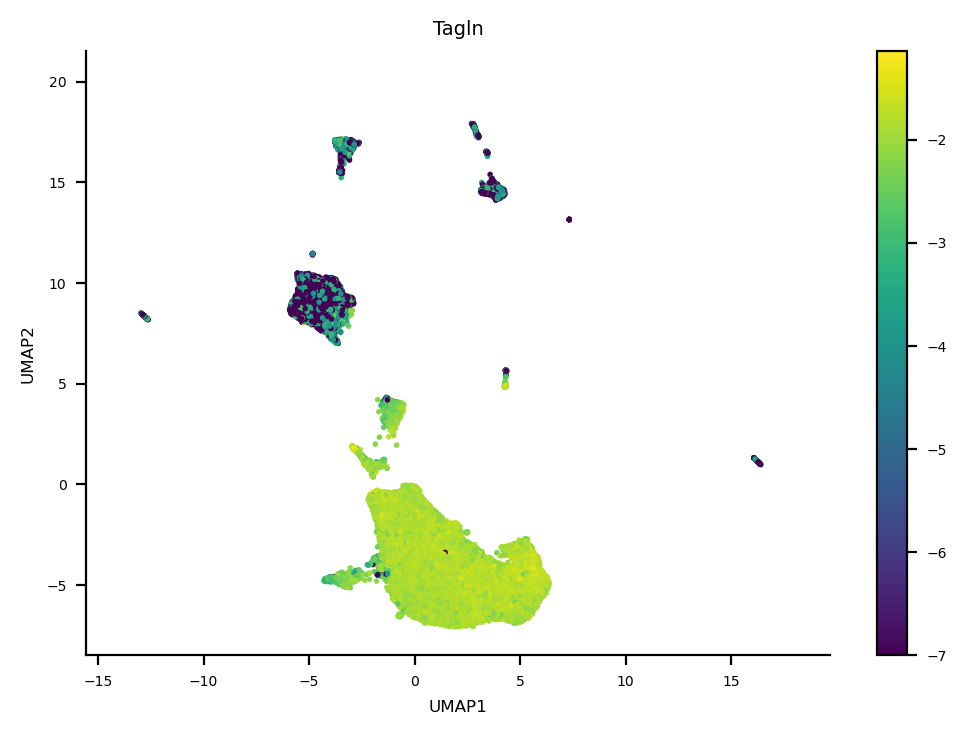

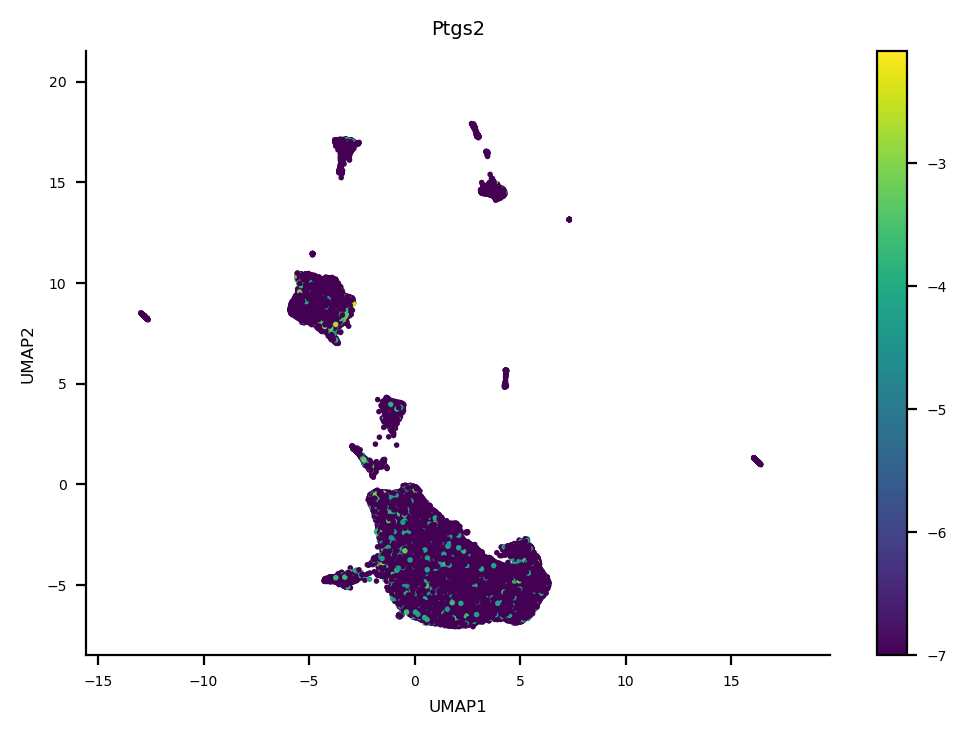

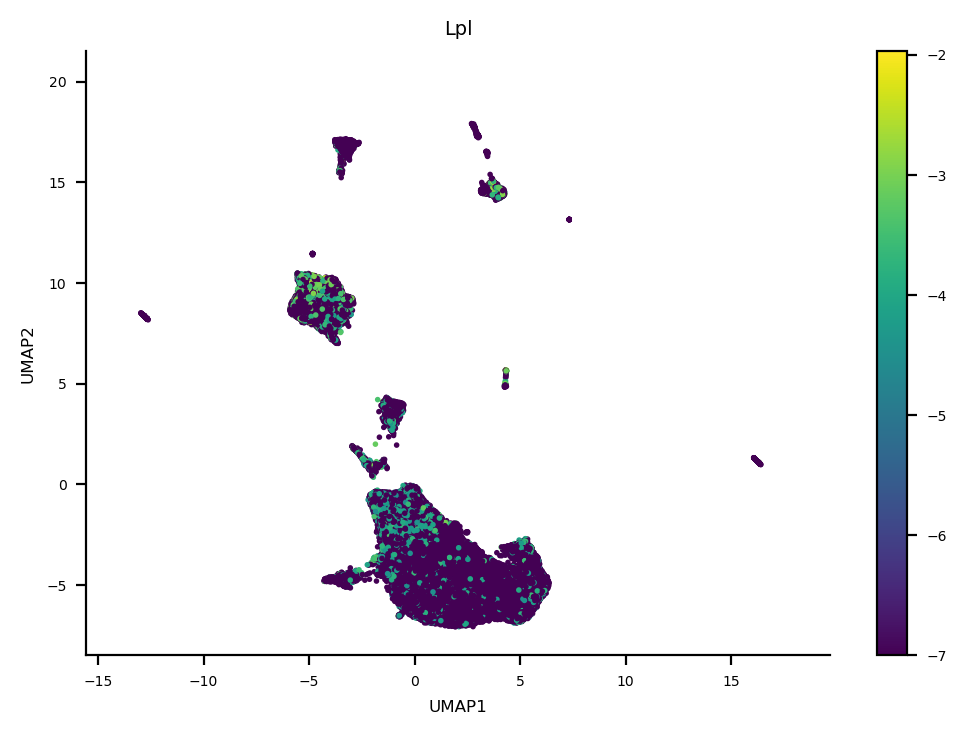

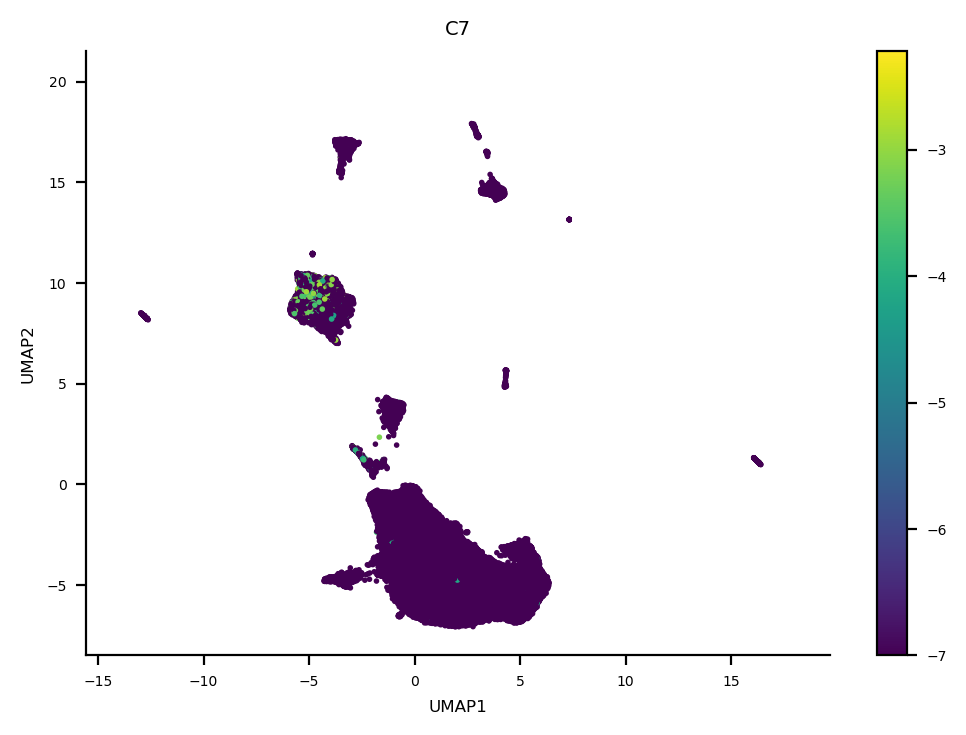

In [33]:
# --- VIZ ---

# get min and max vals
x_min,y_min = np.min(sub_adata.obsm['X_scVI_umap'],axis=0)
x_max,y_max = np.max(sub_adata.obsm['X_scVI_umap'],axis=0)
x_min = x_min - np.abs(x_min) * 0.2
y_min = y_min - np.abs(y_min) * 0.2
x_max = x_max + np.abs(x_max) * 0.2
y_max = y_max + np.abs(y_max) * 0.2



# make plot for each time point
for gene in genes_of_interest:
    

    # viz
    fig,ax = plt.subplots(dpi=200)
    sns.despine()
    plt.scatter(sub_adata.obsm['X_scVI_umap'][:,0], sub_adata.obsm['X_scVI_umap'][:,1],s=1,c=sub_adata[:,gene].layers['X_transformed'].flatten())
    plt.xlim((x_min,x_max))
    plt.ylim((y_min,y_max))
    plt.title((gene))
    plt.colorbar()
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.show()
        
        
        
        
        